Date: 20/08/2024
Desc: To find the minimum throughput to use as threshold for anomaly detection.
      Find the minimum throughput for each link for each USI.

## Imports

In [1]:
import pandas as pd # for data manipulation 
import numpy as np
# import matplotlib.pyplot as plt # for drawing graphs
import os, glob
from tqdm import tqdm
from multiprocessing.pool import Pool
from itertools import repeat

## Using single thread

In [2]:
# Load the data
DATASET_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_train_processed"
# scenario_files = glob.glob(DATASET_PATH + "/*")

usi_list = [10, 20, 66.7, 100]
usi_min_throughput = []

run_num_range = 100 # Take runs 0 - 99
run_num_filter = ["Run-{}".format(num) for num in np.arange(run_num_range)] 

for usi in usi_list:
    # usi_scenarios = [scenario for scenario in scenario_files if "_UAVSendingInterval-{}".format(usi) in scenario]
    usi_scenarios = glob.glob(DATASET_PATH + "/*_UAVSendingInterval-{}".format(usi))
    dl_df_list = []
    ul_df_list = []
    vid_df_list = []
    for scenario in tqdm(usi_scenarios):
        # Downlink
        dl_csv_files = glob.glob(os.path.join(scenario, "*_Downlink_Throughput.csv"))
        dl_csv_files = [file for file in dl_csv_files if (file.split("/")[-1].split("_")[0] in run_num_filter)]
        for file in dl_csv_files:
            dl_df_list.append(pd.read_csv(file))
        # Uplink
        ul_csv_files = glob.glob(os.path.join(scenario, "*_Uplink_Throughput.csv"))
        ul_csv_files = [file for file in ul_csv_files if (file.split("/")[-1].split("_")[0] in run_num_filter)]
        for file in ul_csv_files:
            ul_df_list.append(pd.read_csv(file))
        # Video
        vid_csv_files = glob.glob(os.path.join(scenario, "*_Video_Throughput.csv"))
        vid_csv_files = [file for file in vid_csv_files if (file.split("/")[-1].split("_")[0] in run_num_filter)]
        for file in vid_csv_files:
            vid_df_list.append(pd.read_csv(file))

    dl_df = pd.concat(dl_df_list)
    ul_df = pd.concat(ul_df_list)
    vid_df = pd.concat(vid_df_list)

    dl_min_throughput = dl_df["Throughput"].min()
    ul_min_throughput = ul_df["Throughput"].min()
    vid_min_throughput = vid_df["Throughput"].min()

    dl_max_throughput = dl_df["Throughput"].max()
    ul_max_throughput = ul_df["Throughput"].max()
    vid_max_throughput = vid_df["Throughput"].max()

    usi_min_throughput.append({"USI": usi, "DL_Min_Throughput": dl_min_throughput, "UL_Min_Throughput": ul_min_throughput, "VID_Min_Throughput": vid_min_throughput, 
                               "DL_Max_Throughput": dl_max_throughput, "UL_Max_Throughput": ul_max_throughput, "VID_Max_Throughput": vid_max_throughput})

usi_min_throughput_df = pd.DataFrame(usi_min_throughput)
usi_min_throughput_df.to_csv("/home/research-student/omnet-fanet/data-processing-scripts/journal_3_scripts/data_manual_throughput_min_max.csv")

  0%|          | 0/192 [00:00<?, ?it/s]

100%|██████████| 135/135 [25:45<00:00, 11.45s/it]


## Using Multiprocessing

In [7]:
# Load the data
DATASET_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_train_processed"
RELIABILITY_TH = 0.999
NUM_PROCS = 32
# scenario_files = glob.glob(DATASET_PATH + "/*")

usi_list = [10, 20, 66.7, 100]
usi_min_throughput = []

def load_throughput(scenario, reliability_th, run_num_filter=None):
    print(scenario)
    dl_df_list = []
    ul_df_list = []
    vid_df_list = []
    # Downlink
    dl_csv_files = glob.glob(os.path.join(scenario, "*_Downlink_Throughput.csv"))
    if run_num_filter != None:
        dl_csv_files = [file for file in dl_csv_files if (file.split("/")[-1].split("_")[0] in run_num_filter)]
    for file in dl_csv_files:
        dl_df_list.append(pd.read_csv(file))
    # Uplink
    ul_csv_files = glob.glob(os.path.join(scenario, "*_Uplink_Throughput.csv"))
    if run_num_filter != None:
        ul_csv_files = [file for file in ul_csv_files if (file.split("/")[-1].split("_")[0] in run_num_filter)]
    for file in ul_csv_files:
        ul_df_list.append(pd.read_csv(file))
    # Video
    vid_csv_files = glob.glob(os.path.join(scenario, "*_Video_Throughput.csv"))
    if run_num_filter != None:
        vid_csv_files = [file for file in vid_csv_files if (file.split("/")[-1].split("_")[0] in run_num_filter)]
    for file in vid_csv_files:
        vid_df_list.append(pd.read_csv(file))
    
    dl_df = pd.concat(dl_df_list)
    ul_df = pd.concat(ul_df_list)
    vid_df = pd.concat(vid_df_list)

    # Remove data where measured reliability < threshold
    dl_df = dl_df.loc[dl_df["Measured_Reliability"] >= reliability_th]
    ul_df = ul_df.loc[ul_df["Measured_Reliability"] >= reliability_th]
    vid_df = vid_df.loc[vid_df["Measured_Reliability"] >= reliability_th]

    # Remove data where time < 1
    dl_df = dl_df.loc[dl_df["Time"] >= 1]
    ul_df = ul_df.loc[ul_df["Time"] >= 1]
    vid_df = vid_df.loc[vid_df["Time"] >= 1]

    return (dl_df["Throughput"].min(), ul_df["Throughput"].min(), vid_df["Throughput"].min(), dl_df["Throughput"].max(), ul_df["Throughput"].max(), vid_df["Throughput"].max())

for usi in usi_list:
    # usi_scenarios = [scenario for scenario in scenario_files if "_UAVSendingInterval-{}".format(usi) in scenario]
    usi_scenarios = glob.glob(DATASET_PATH + "/*_UAVSendingInterval-{}".format(usi))
    dl_min_list = []
    ul_min_list = []
    vid_min_list = []
    dl_max_list = []
    ul_max_list = []
    vid_max_list = []
    
    with Pool(NUM_PROCS) as pool:
        for result in pool.starmap(load_throughput, zip(usi_scenarios, repeat(RELIABILITY_TH))):
            dl_min_list.append(result[0])
            ul_min_list.append(result[1])
            vid_min_list.append(result[2])
            dl_max_list.append(result[3])
            ul_max_list.append(result[4])
            vid_max_list.append(result[5])
  
    dl_min_throughput = np.nanmin(dl_min_list)
    ul_min_throughput = np.nanmin(ul_min_list)
    vid_min_throughput = np.nanmin(vid_min_list)

    dl_max_throughput = np.nanmax(dl_max_list)
    ul_max_throughput = np.nanmax(ul_max_list)
    vid_max_throughput = np.nanmax(vid_max_list)

    usi_min_throughput.append({"USI": usi, "DL_Min_Throughput": dl_min_throughput, "UL_Min_Throughput": ul_min_throughput, "VID_Min_Throughput": vid_min_throughput, 
                               "DL_Max_Throughput": dl_max_throughput, "UL_Max_Throughput": ul_max_throughput, "VID_Max_Throughput": vid_max_throughput})

usi_min_throughput_df = pd.DataFrame(usi_min_throughput)
usi_min_throughput_df.to_csv("/home/research-student/omnet-fanet/data-processing-scripts/journal_3_scripts/data_manual_throughput_min_max_21102024.csv")

/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_train_processed/UAVSpeed-21_BitRate-52_Height-60_Distance-80_Modulation-QAM-64_UAVSendingInterval-10/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_train_processed/UAVSpeed-26_BitRate-26_Height-150_Distance-140_Modulation-QAM-16_UAVSendingInterval-10/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_train_processed/UAVSpeed-26_BitRate-26_Height-180_Distance-140_Modulation-QAM-16_UAVSendingInterval-10/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_train_processed/UAVSpeed-11_BitRate-39_Height-90_Distance-130_Modulation-QAM-16_UAVSendingInterval-10/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_train_proc

/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_train_processed/UAVSpeed-21_BitRate-65_Height-100_Distance-70_Modulation-QAM-64_UAVSendingInterval-10
/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_train_processed/UAVSpeed-11_BitRate-26_Height-190_Distance-140_Modulation-QAM-16_UAVSendingInterval-10
/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_train_processed/UAVSpeed-11_BitRate-26_Height-270_Distance-30_Modulation-QAM-16_UAVSendingInterval-10
/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_train_processed/UAVSpeed-26_BitRate-65_Height-90_Distance-70_Modulation-QAM-64_UAVSendingInterval-10
/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_train_p

In [52]:
# Load the data
DATASET_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_train_custom_2_processed"
RELIABILITY_TH = 0.999
NUM_PROCS = 32
# scenario_files = glob.glob(DATASET_PATH + "/*")

usi_list = [10]
usi_min_throughput = []

def load_throughput(scenario, reliability_th, run_num_filter=None):
    ul_df_min_list = []
    run_num_list = []
    # Uplink
    ul_csv_files = glob.glob(os.path.join(scenario, "*_Uplink_Throughput.csv"))
    if run_num_filter != None:
        ul_csv_files = [file for file in ul_csv_files if (file.split("/")[-1].split("_")[0] in run_num_filter)]
    for file in ul_csv_files:
        ul_df = pd.read_csv(file)
        ul_df = ul_df.loc[ul_df["Measured_Reliability"] >= reliability_th]
        ul_df_min_list.append(ul_df["Throughput"].min())
        run_num_list.append(file.split("/")[-1].split("_")[0])

    data = {"Run_Num": run_num_list, "UL_Min": ul_df_min_list}
    df = pd.DataFrame(data)

    return (df)

for usi in usi_list:
    # usi_scenarios = [scenario for scenario in scenario_files if "_UAVSendingInterval-{}".format(usi) in scenario]
    usi_scenarios = glob.glob(DATASET_PATH + "/*_UAVSendingInterval-{}".format(usi))
    
    with Pool(NUM_PROCS) as pool:
        for result in pool.starmap(load_throughput, zip(usi_scenarios, repeat(RELIABILITY_TH))):
            df = result
  

## Plot Histogram of Throughput Values

In [28]:
# Load the data
DATASET_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_uav_interference/uav_scenario_0_processed"
LINK = "Uplink"
# RELIABILITY_TH = 0.999
RELIABILITY_TH = 0 # Don't filter by reliability
NUM_PROCS = 32
# scenario_files = glob.glob(DATASET_PATH + "/*")

usi_list = [10]
usi_min_throughput = []

def load_throughput_link(scenario, reliability_th, link, run_num_filter=None):
    
    assert link in ["Downlink", "Uplink", "Video"], "link should be either 'Downlink', 'Uplink', or 'Video'"
    df_list = []
    csv_files = glob.glob(os.path.join(scenario, "*_{}_Throughput.csv".format(link)))
    if run_num_filter != None:
        csv_files = [file for file in csv_files if (file.split("/")[-1].split("_")[0] in run_num_filter)]
    for file in csv_files:
        df_list.append(pd.read_csv(file))
    
    df = pd.concat(df_list)
    df = df.loc[df["Measured_Reliability"] >= reliability_th]

    return df

for usi in usi_list:
    # usi_scenarios = glob.glob(DATASET_PATH + "/*_UAVSendingInterval-{}".format(usi)) # For no interference case
    usi_scenarios = glob.glob(DATASET_PATH + "/*_UAVSendingInterval-{}_*".format(usi)) # For interference case
    df_list = []
    
    with Pool(NUM_PROCS) as pool:
        for result in pool.starmap(load_throughput_link, zip(usi_scenarios, repeat(RELIABILITY_TH), repeat(LINK))):
            df_list.append(result)

    df = pd.concat(df_list)

print(df["Throughput"].mean(), df["Throughput"].std())


109740.14695544349 174198.22742512077


Text(0.5, 0, 'Throughput (bytes/s)')

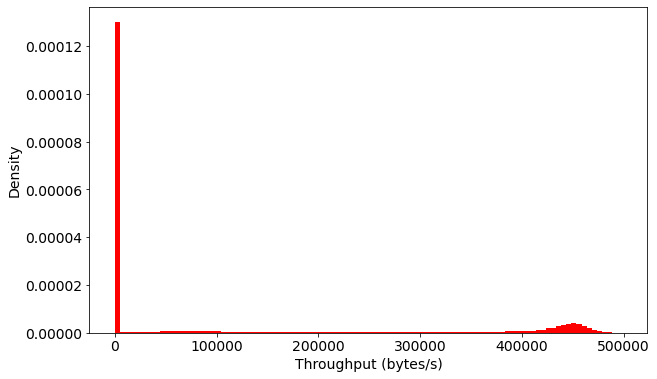

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
plt.hist(df["Throughput"].values, bins=100, density=True, color='red')
plt.ylabel("Density")
plt.xlabel("Throughput (bytes/s)")

Text(0.5, 0, 'Packet Size (bytes)')

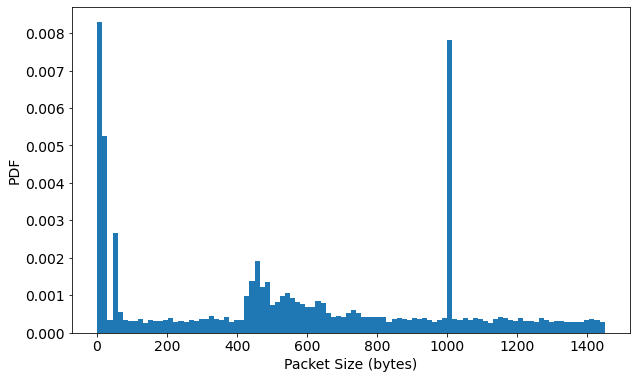

In [13]:
# Plot histogram for packet size

pkt_size_df = pd.read_csv("/home/research-student/omnet-fanet/uav_traffic_csv/djispark_ul.csv")
plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
plt.hist(pkt_size_df["Packet_len"].values, bins=100, density=True)
plt.ylabel("PDF")
plt.xlabel("Packet Size (bytes)")

In [24]:
pkt_size_df["Packet_len"].value_counts(normalize=True, ascending=True)[12]

0.07622184320414045